In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
# Прочитайте данные (переменную назовите 'df')
df = pd.read_csv('data.csv')

# Вывести несколько первых строк таблицы данных
print(df.head())

   Unnamed: 0  Student_id  Age      Grade Employed  marks
0           0           1   19  1st Class      yes     29
1           1           2   20  2nd Class       no     41
2           2           3   18  1st Class       no     57
3           3           4   21  2nd Class       no     29
4           4           5   19  1st Class       no     57


In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('data-2.csv')
df.columns = df.columns.str.strip()

print(df.columns)
print(df.head())

df['Дата'] = pd.to_datetime(df['Дата'])

Index(['Дата', 'Склад', 'Контрагент', 'Номенклатура', 'Количество'], dtype='object')
         Дата  Склад Контрагент Номенклатура  Количество
0  2018-01-04      1  address_0    product_0           4
1  2018-01-04      1  address_0    product_1           4
2  2018-01-04      1  address_0    product_2           5
3  2018-01-04      1  address_0    product_3          10
4  2018-01-04      1  address_0    product_4           2


Проверяем формат столбцов

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301355 entries, 0 to 301354
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   Дата          301355 non-null  datetime64[ns]
 1   Склад         301355 non-null  int64         
 2   Контрагент    301355 non-null  object        
 3   Номенклатура  301355 non-null  object        
 4   Количество    301355 non-null  int64         
dtypes: datetime64[ns](1), int64(2), object(2)
memory usage: 11.5+ MB


Сразу переведем столбец "Дата" в правильный формат

In [13]:
df['Дата'] = pd.to_datetime(df['Дата'])

Сгруппируйте данные по дате, посчитайте количество продаж

In [16]:
grouped_df = df.groupby('Дата').size().reset_index(name='sales_count')

Вывести несколько первых строк сгруппированных данных

In [17]:
print(grouped_df.head())

        Дата  sales_count
0 2018-01-04         1840
1 2018-01-05         1301
2 2018-01-06         1306
3 2018-01-07         1322
4 2018-01-09         1719


Нарисуйте график продаж у `grouped_df`

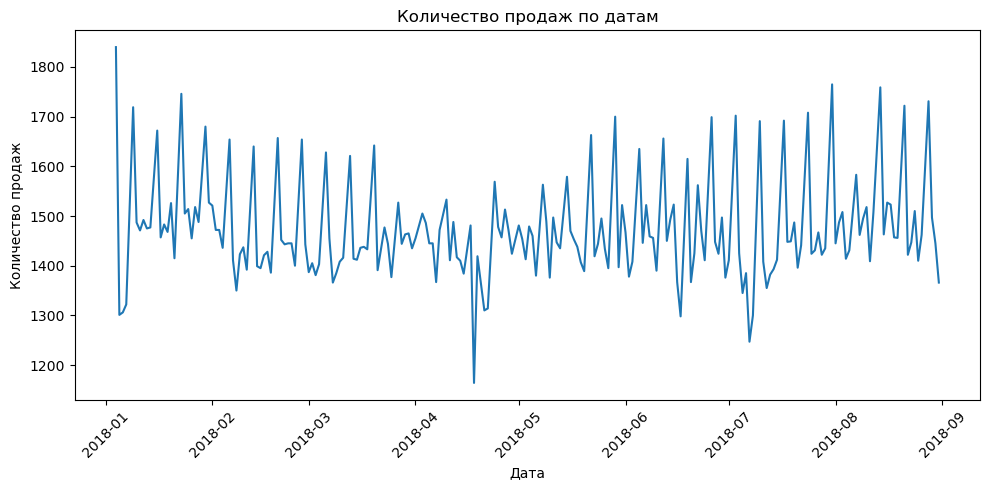

In [18]:
plt.figure(figsize=(10,5))
plt.plot(grouped_df['Дата'], grouped_df['sales_count'])

plt.title('Количество продаж по датам')
plt.xlabel('Дата')
plt.ylabel('Количество продаж')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Опишите что вы видите на графике. Ваша задача - максимально описать график

In [ ]:
#На графике видно, что продажи меняются от дня к дню: 
#есть дни с резкими скачками и дни со снижением. 
#В целом стабильности нет, наблюдаются отдельные пики — 
#это может быть связано с повышенным спросом или какими-то событиями

Найдите строку, у которой максимальный выброс по количеству продаж (нужно найти выброс у `df`)

In [21]:
max_row = grouped_df.loc[grouped_df['sales_count'].idxmax()]
print(max_row)

Дата           2018-01-04 00:00:00
sales_count                   1840
Name: 0, dtype: object


Найдите топовый товар по продажам по средам за июнь, июль, август у 3 склада

In [22]:
df['weekday'] = df['Дата'].dt.day_name()
filtered = df[
    (df['weekday'] == 'Wednesday') &
    (df['Дата'].dt.month.isin([6, 7, 8]))
]

top_products = (
    filtered.groupby(['Склад', 'Номенклатура'])
    .size()
    .reset_index(name='sales_count')
    .sort_values(['Склад', 'sales_count'], ascending=[True, False])
)

top_products = top_products.groupby('Склад').head(1)

print(top_products)

    Склад Номенклатура  sales_count
1       1    product_1          339
24      2    product_1          643
46      3    product_1          521
69      4    product_1          295
92      5    product_1          354


Скачайте данные по погоде с https://rp5.ru/Архив_погоды_в_Астане (скачайте исходные данные, и далее преобразуйте так, чтобы мы имели Дату и Среднюю температуру за день), объедините таблицу температуры с `grouped_df`, и нарисуйте график `y=['Количество продаж', 'T']`, где Т это температура. А также отдельно график температуры.

In [24]:
weather = pd.read_csv(
    '35188.30.03.2026.30.03.2026.1.0.0.ru.utf8.00000000.csv',
    sep=';',
    comment='#',
    encoding='utf-8'
)

print(weather.head())

                  Местное время в Астане      T     Po    P  Pa  \
30.03.2026 20:00                    11.0  730.2  761.3 -0.4  59   
30.03.2026 17:00                    15.3  730.6  761.2 -0.6  39   
30.03.2026 14:00                    14.1  731.2  762.1 -0.9  42   
30.03.2026 11:00                    11.2  732.1  763.3 -0.3  50   
30.03.2026 08:00                     5.6  732.4  764.2  0.0  81   

                                                U  DD  Ff  ff10           ff3  \
30.03.2026 20:00           Ветер, дующий с севера   1 NaN   NaN  Облаков нет.   
30.03.2026 17:00  Ветер, дующий с юго-юго-востока   1 NaN   NaN  Облаков нет.   
30.03.2026 14:00              Ветер, дующий с юга   2 NaN   NaN  Облаков нет.   
30.03.2026 11:00              Ветер, дующий с юга   1 NaN   NaN  Облаков нет.   
30.03.2026 08:00              Ветер, дующий с юга   2 NaN   NaN  Облаков нет.   

                  ...  Cm   Ch   VV  Td  RRR  tR   E  \
30.03.2026 20:00  ... NaN  NaN  3.1 NaN  NaN NaN NaN  

In [38]:
weather.columns = weather.columns.str.strip()
print(weather.columns)

Index(['Дата', 'T'], dtype='object')


In [39]:
weather = weather[['Дата', 'T']]

weather['Дата'] = pd.to_datetime(weather['Дата'], dayfirst=True)

weather = weather.groupby('Дата', as_index=False)['T'].mean()

print(weather.head())

        Дата           T
0 1970-01-01  731.614286


In [40]:
grouped_df['Дата'] = pd.to_datetime(grouped_df['Дата'])

merged = pd.merge(grouped_df, weather, on='Дата', how='left')

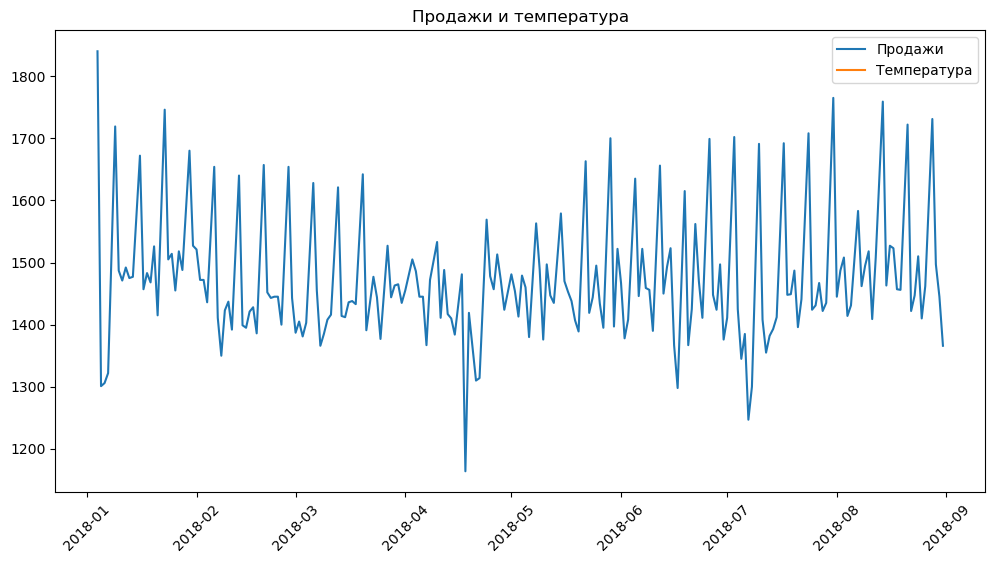

In [41]:
plt.figure(figsize=(12,6))
plt.plot(merged['Дата'], merged['sales_count'], label='Продажи')
plt.plot(merged['Дата'], merged['T'], label='Температура')

plt.legend()
plt.xticks(rotation=45)
plt.title('Продажи и температура')
plt.show()

In [ ]:
#Температура в течение периода менялась постепенно, без резких постоянных скачков. 
#Видно общее изменение погодных условий по сезонам